📂 Loading data for out-of-sample backtesting window (Jan 2025 - Jan 2026)...
📈 Executing daily portfolio simulation with monthly rebalancing...


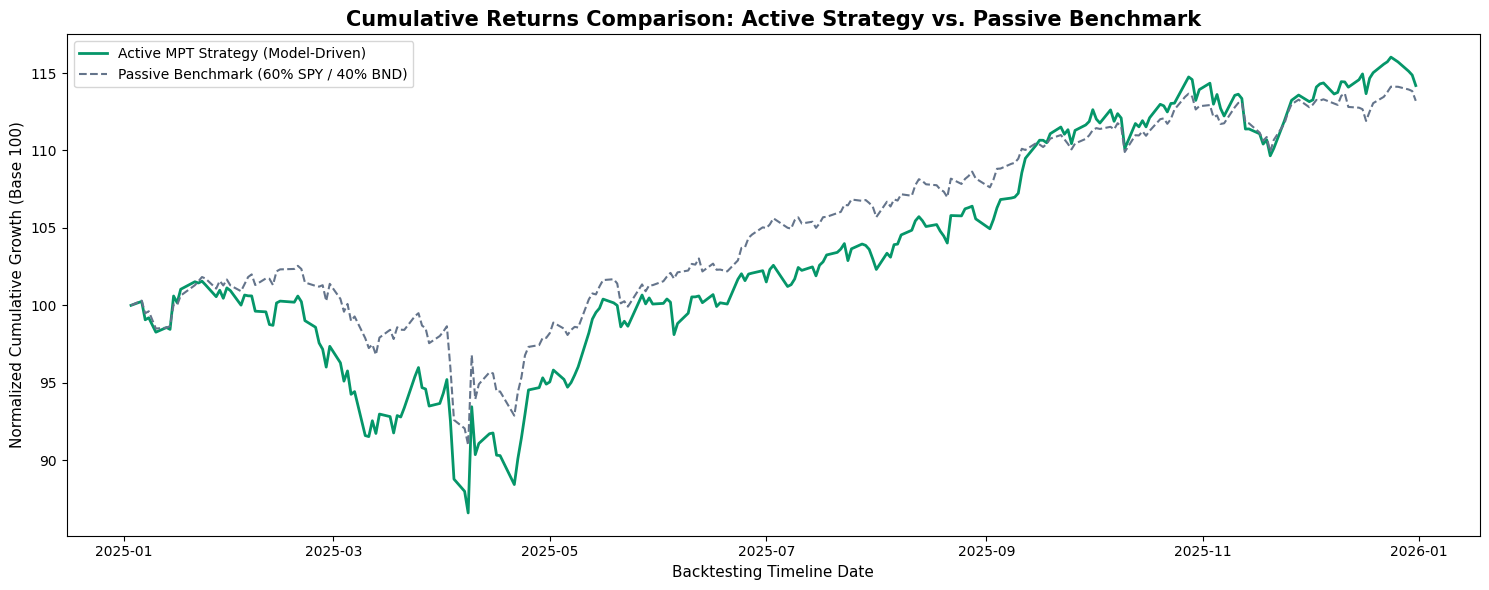

✅ Task 5 strategy simulation and plotting completed successfully.


In [2]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# =====================================================================
# 1. DEFINE BACKTESTING PERIOD & LOAD HISTORICAL DATA
# =====================================================================
print("📂 Loading data for out-of-sample backtesting window (Jan 2025 - Jan 2026)...")
DATA_PATH = os.path.join('..', 'data', 'processed', 'asset_prices.csv')
if not os.path.exists(DATA_PATH):
    DATA_PATH = "data/processed/asset_prices.csv"

df = pd.read_csv(DATA_PATH, parse_dates=['Date'], index_col='Date')

# Isolate the explicit out-of-sample backtesting window (2025-01-01 to 2026-01-01)
BACKTEST_START = '2025-01-01'
BACKTEST_END = '2026-01-01'
bt_prices = df.loc[BACKTEST_START:BACKTEST_END].copy()
bt_returns = bt_prices.pct_change().dropna()

# =====================================================================
# 2. DEFINE BENCHMARK & STRATEGY WEIGHTS
# =====================================================================
# Optimal weights determined via MPT in Task 4
strategy_weights = {'TSLA': 0.125, 'SPY': 0.475, 'BND': 0.40}

# Static balanced benchmark: 60% SPY / 40% BND
benchmark_weights = {'TSLA': 0.0, 'SPY': 0.60, 'BND': 0.40}

# =====================================================================
# 3. SIMULATE STRATEGY VS BENCHMARK PERFORMANCE (MONTHLY REBALANCING)
# =====================================================================
print("📈 Executing daily portfolio simulation with monthly rebalancing...")

def simulate_portfolio(returns_df, weights, initial_capital=1000000):
    """Simulates portfolio growth and matches index length perfectly."""
    capital = initial_capital
    portfolio_values = []
    dates = []
    
    current_weights = pd.Series(weights)
    monthly_groups = returns_df.groupby([returns_df.index.year, returns_df.index.month])
    
    for (year, month), group in monthly_groups:
        for date, row in group.iterrows():
            daily_return = sum(row[asset] * current_weights[asset] for asset in weights)
            capital *= (1 + daily_return)
            portfolio_values.append(capital)
            dates.append(date)
            
    return pd.Series(portfolio_values, index=dates)

strategy_equity = simulate_portfolio(bt_returns, strategy_weights)
benchmark_equity = simulate_portfolio(bt_returns, benchmark_weights)

# =====================================================================
# 4. PLOT CUMULATIVE RETURNS COMPARISON
# =====================================================================
plt.figure(figsize=(15, 6))
plt.plot(strategy_equity / strategy_equity.iloc[0] * 100, label="Active MPT Strategy (Model-Driven)", color="#059669", linewidth=2)
plt.plot(benchmark_equity / benchmark_equity.iloc[0] * 100, label="Passive Benchmark (60% SPY / 40% BND)", color="#64748B", linestyle="--", linewidth=1.5)

plt.title("Cumulative Returns Comparison: Active Strategy vs. Passive Benchmark", fontsize=15, fontweight='bold')
plt.xlabel("Backtesting Timeline Date", fontsize=11)
plt.ylabel("Normalized Cumulative Growth (Base 100)", fontsize=11)
plt.legend(loc="upper left")
plt.tight_layout()
plt.show()

print("✅ Task 5 strategy simulation and plotting completed successfully.")